In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer

In [3]:
df=pd.read_csv('titanic.csv')

In [4]:
df.head(-10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


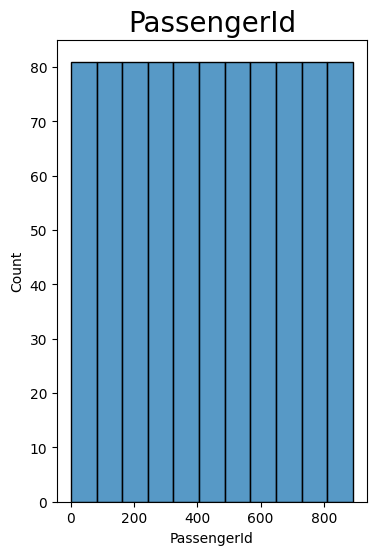

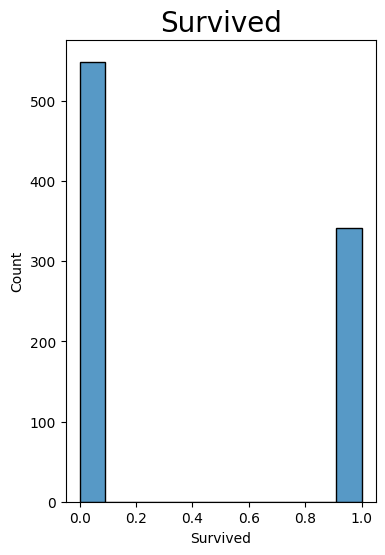

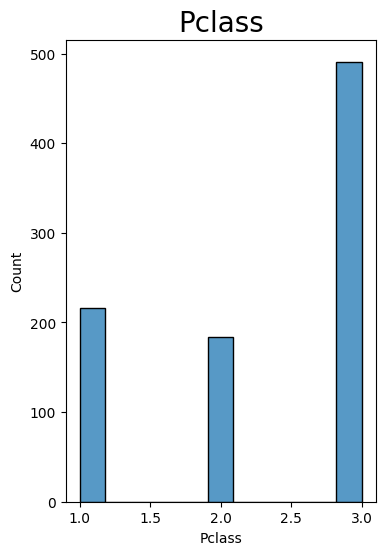

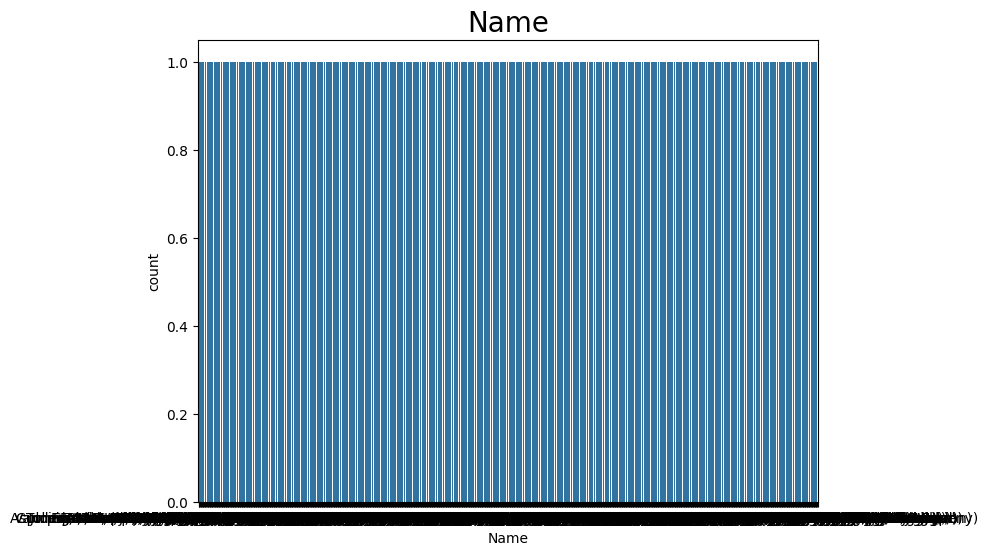

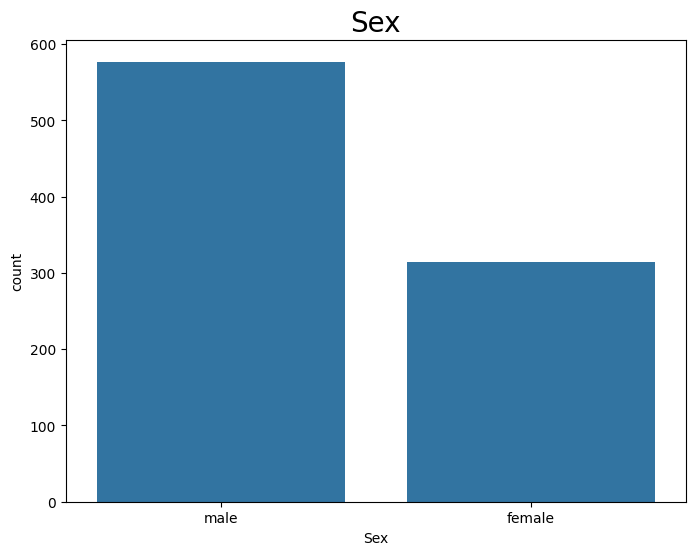

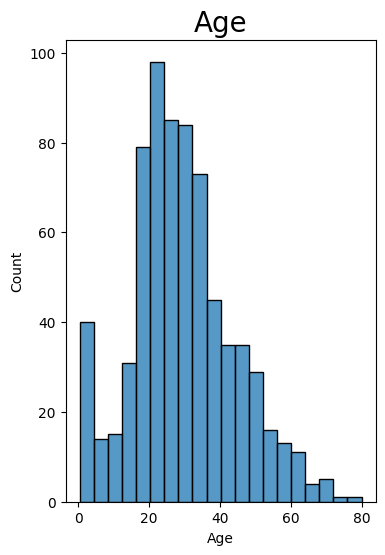

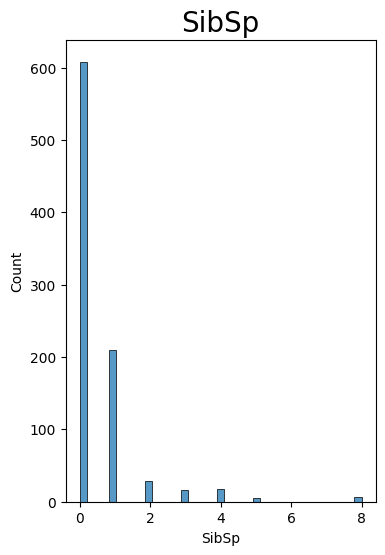

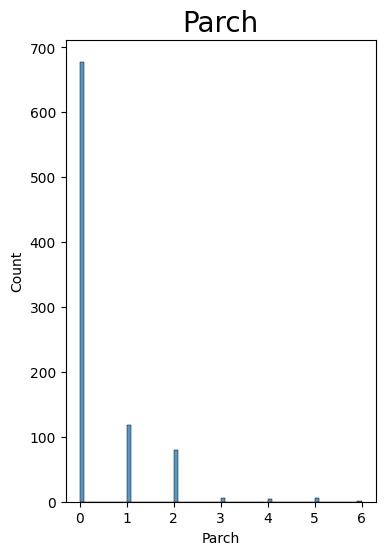

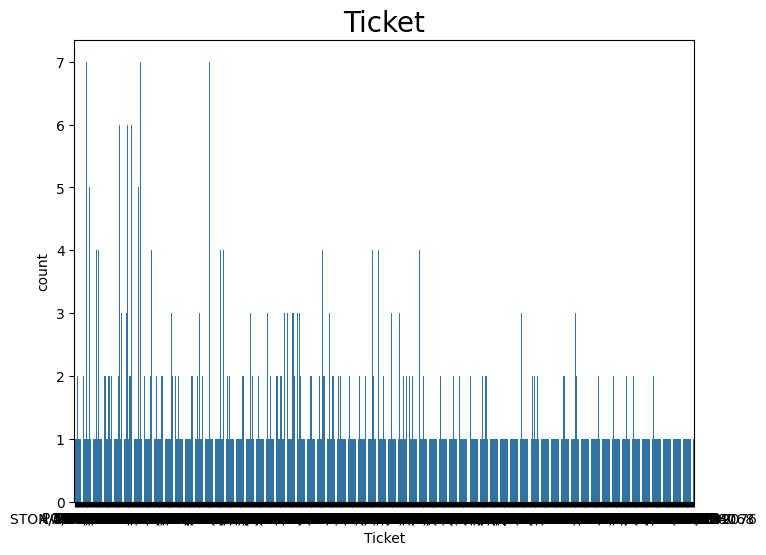

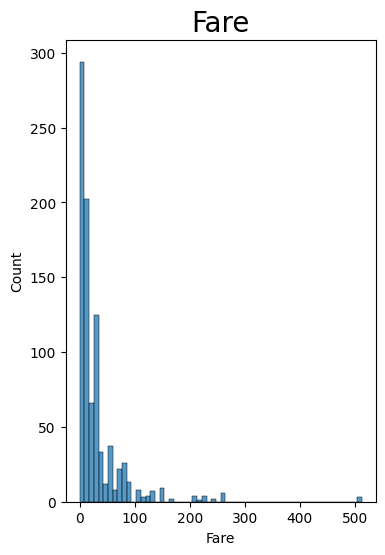

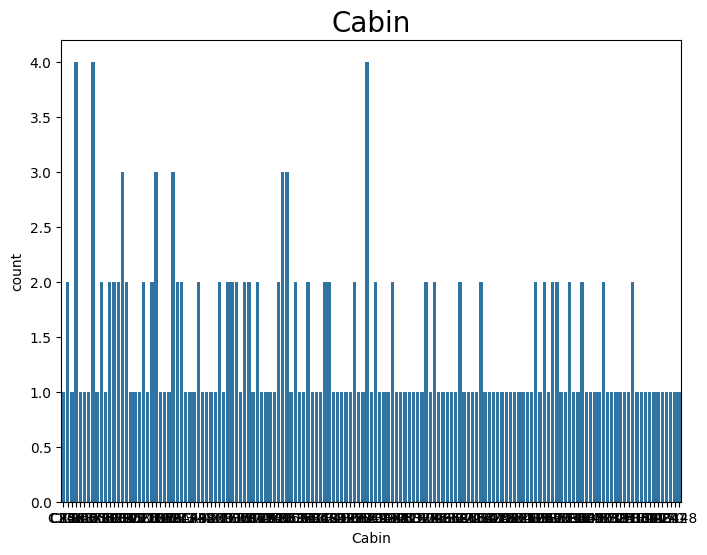

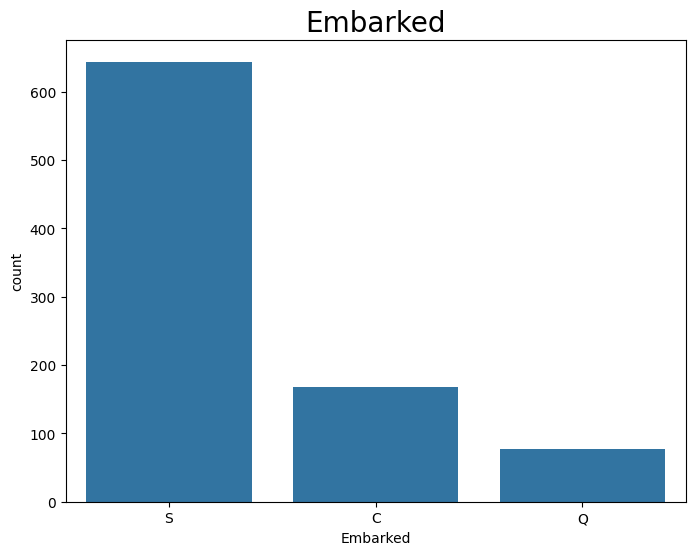

In [8]:
for col in df.columns:
    if df[col].dtype=='object':
        plt.figure(figsize=(8,6))
        sns.countplot(data=df,x=col)
        plt.title(col,fontsize=20)
        plt.show()
    else:
        plt.figure(figsize=(4,6))
        sns.histplot(data=df,x=col)
        plt.title(col,fontsize=20)
        plt.show()

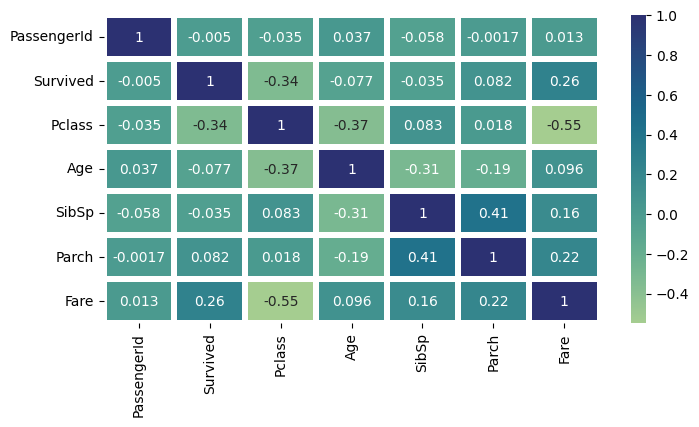

In [9]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='crest',lw=3)
plt.show()

In [156]:
df.head(-1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,75722,0,3,"Robinson, Master. Steven",male,55.6,2,3,600542,3.02,Q
1,80185,1,2,"Wilson, Master. Richard",male,85.0,1,0,561216,8.68,S
2,19865,1,2,"Taylor, Ms. Betty",female,NaN,0,0,589751,4.61,S
3,76700,1,3,"Smith, Mrs. Elizabeth",female,13.3,0,0,96366,5.56,S
4,92992,0,1,"Jackson, Rev. Daniel",male,55.9,0,1,416388,40.64,S
...,...,...,...,...,...,...,...,...,...,...,...
99994,82387,1,1,"Robinson, Ms. Mary",female,38.1,0,1,481773,25.52,S
99995,6266,0,3,"Robinson, Rev. James",male,32.0,1,1,219100,2.53,S
99996,54887,0,3,"Jackson, Mr. Donald",male,25.5,0,0,403270,17.17,S
99997,76821,0,2,"Wilson, Rev. Donald",male,NaN,1,0,345632,12.25,S


In [12]:
import numpy as np

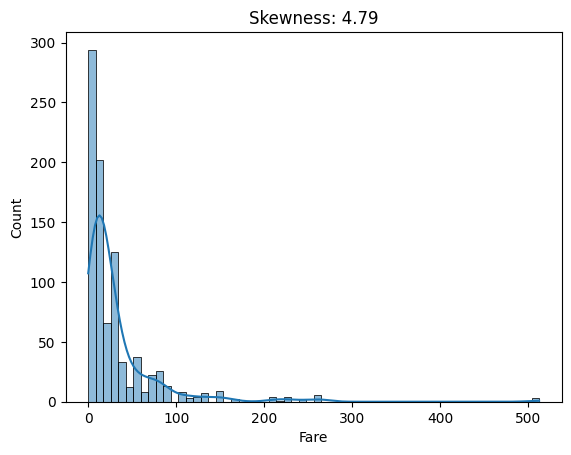

In [57]:
sns.histplot(df['Fare'], kde=True)
plt.title(f"Skewness: {df['Fare'].skew():.2f}")
plt.show()

In [63]:
# Apply log transformation
df['Fare_log'] = np.log1p(df['Fare'])

# Check the new skewness
print(f"Original Skew: {df['Fare'].skew():.2f}")
print(f"Transformed Skew: {df['Fare_log'].skew():.2f}")

Original Skew: 4.79
Transformed Skew: 0.39


<Axes: xlabel='Fare', ylabel='Count'>

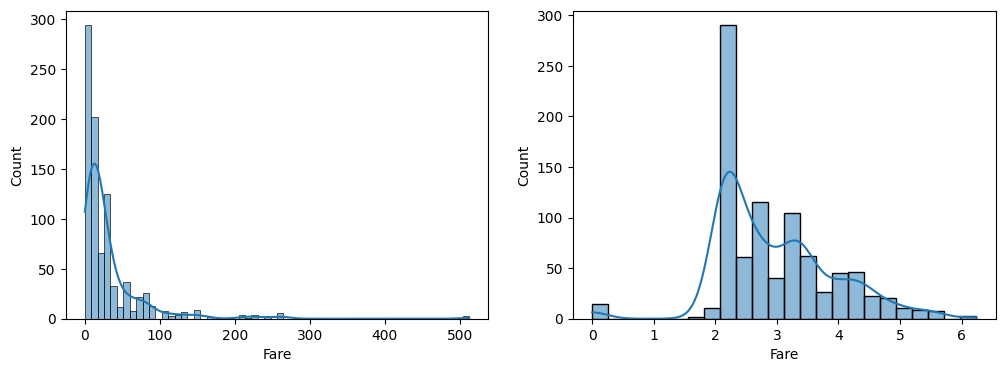

In [56]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
sns.histplot(df.Fare,kde=True,ax=axes[0])
sns.histplot(np.log1p(df.Fare),kde=True,ax=axes[1])



In [182]:
fare_binning = KBinsDiscretizer(
    n_bins=5, 
    encode='ordinal', 
    strategy='quantile',
    quantile_method='averaged_inverted_cdf' 
)

In [185]:
df['binning_fare']=fare_binning.fit_transform(df['Fare'].values.reshape(-1,1))

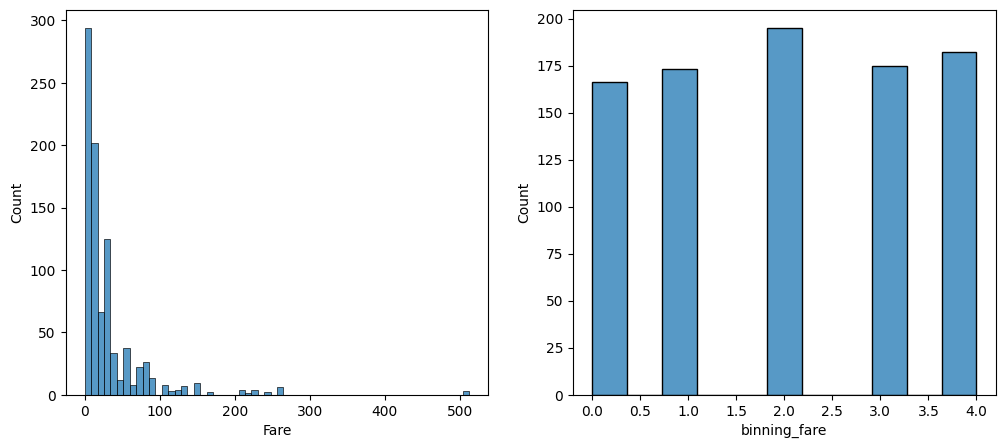

In [189]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x='Fare',ax=axes[0])
sns.histplot(data=df,x='binning_fare',ax=axes[1])
plt.show()

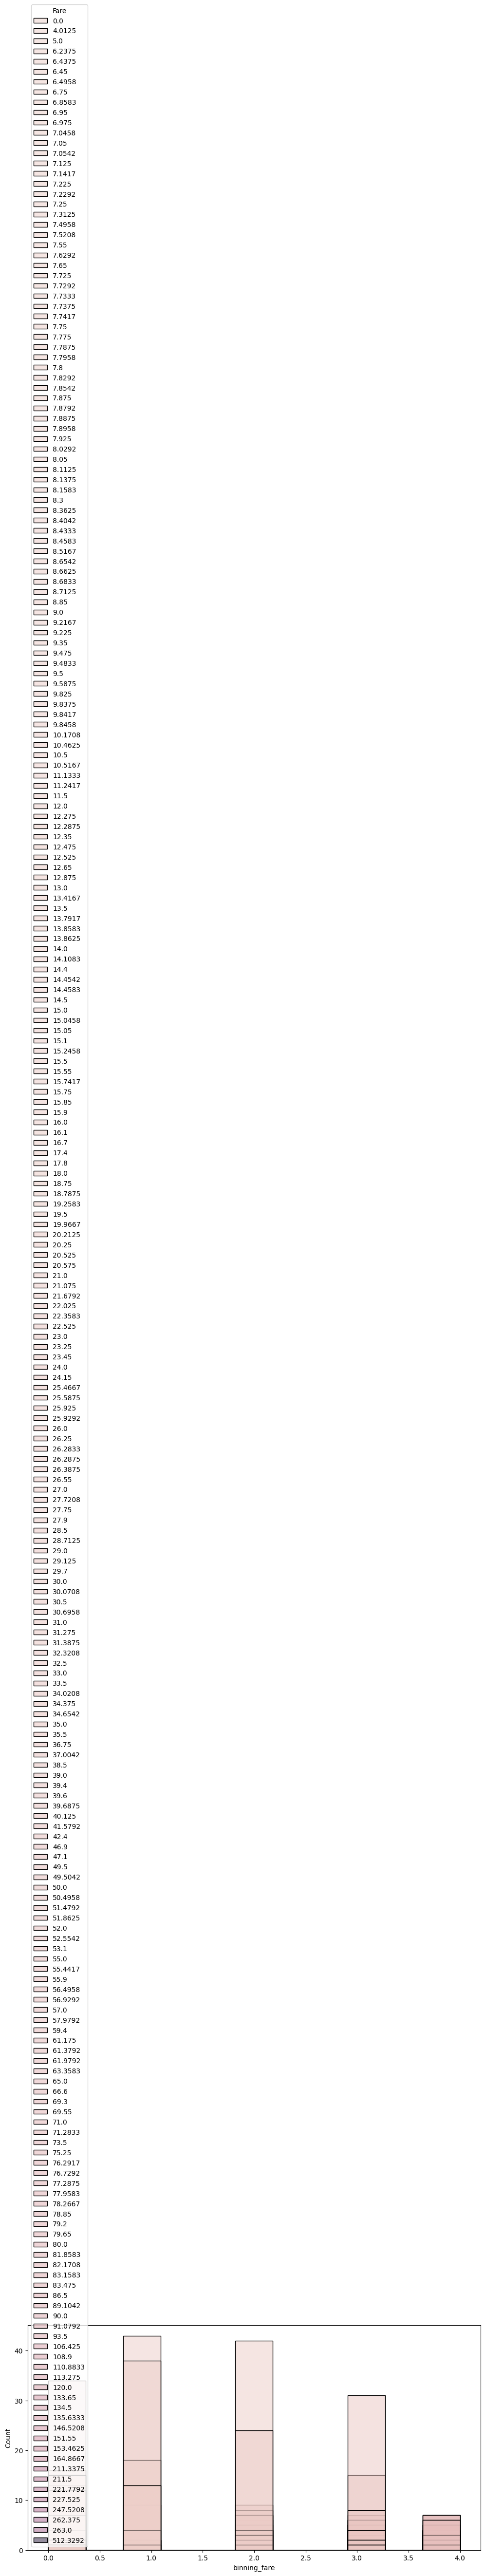

In [194]:
plt.figure(figsize=(12,6))
sns.histplot(data=df,x='binning_fare',hue='Fare')
plt.show()

In [17]:
df['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [89]:
ordinal_features=['Pclass']
numerical_features=['Age','SibSp','Parch']
nominal_features=['Embarked','Sex']
binning_features = ['Fare']

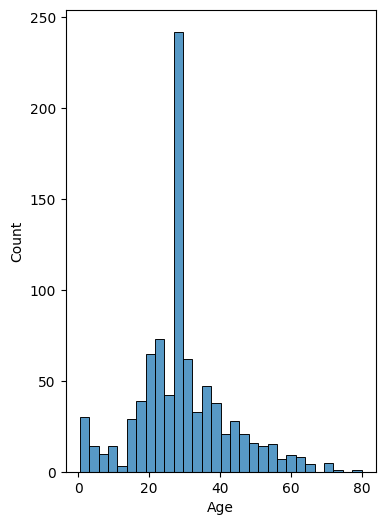

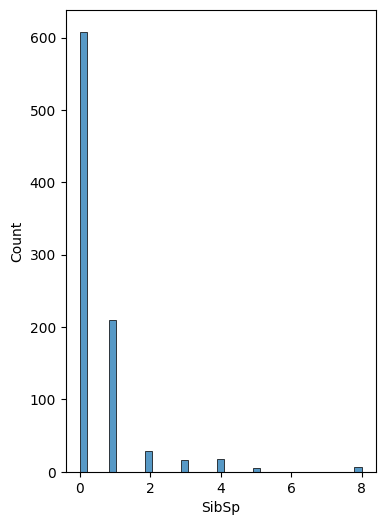

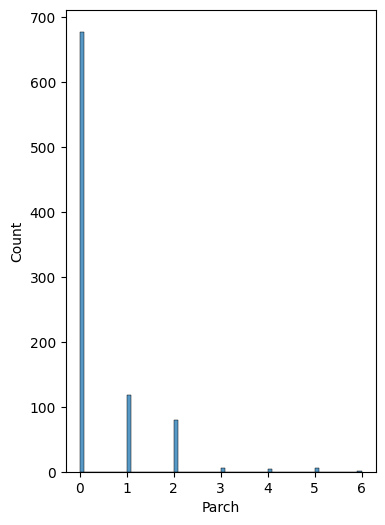

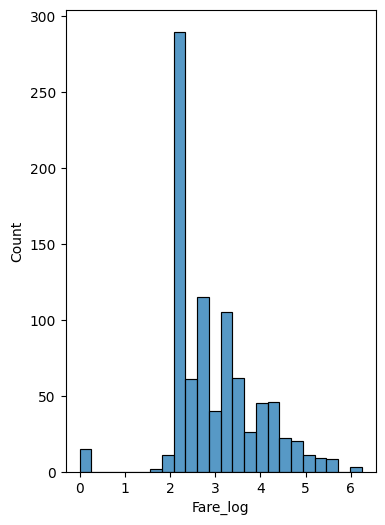

In [66]:
for i in numerical_features:
    plt.figure(figsize=(4,6))
    sns.histplot(df[i])

In [109]:
ordinal_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinal_emcoder',OrdinalEncoder())
])


numerical_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('standardscale',StandardScaler())
])


nominal_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    
     ('onehotencoding',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])
fare_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('binning', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile',quantile_method='averaged_inverted_cdf')),
    ('scaler', StandardScaler())
])

In [28]:
from sklearn.linear_model import LogisticRegression

In [125]:
lr_model = LogisticRegression()

In [24]:
y=df.Survived

In [111]:
preprocessor=ColumnTransformer(transformers=[
    ('num',numerical_pipeline,numerical_features),
    ('ordinal',ordinal_pipeline,ordinal_features),
    ('nominal',nominal_pipeline,nominal_features),
    ('fare_bin', fare_pipeline, binning_features)
])

In [93]:
x=df[numerical_features+nominal_features+ordinal_features+binning_features]

In [126]:
model_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',lr_model)
])

In [95]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=.7,random_state=42)

In [127]:
model_pipeline.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [128]:
predict_y=model_pipeline.predict(x_test)

In [129]:
print(f'accuracy score:{accuracy_score(y_test,predict_y)}')

accuracy score:0.8097014925373134


In [130]:
y1=model_pipeline.predict(x_train)

In [131]:
accuracy_score(y_train,y1)

0.7961476725521669

In [101]:
from sklearn.metrics import f1_score

In [102]:
f1_score(y_test,predict_y)

0.7758620689655172

In [146]:
param_grid = {
    # Number of trees (more is usually better but slower)
    'classifier__n_estimators': [100, 200, 500],
    
    # Depth of trees (prevents the model from memorizing the data)
    'classifier__max_depth': [None, 10, 20],
    
    # Minimum samples required to split a node (higher prevents overfitting)
    'classifier__min_samples_split': [2, 5, 10],
    
    # Number of features to consider at each split
    'classifier__max_features': ['sqrt', 'log2'],
    
    # Handle the class imbalance automatically
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

In [166]:
rf = RandomForestClassifier(
    random_state=42
)

In [167]:
model_pipline_rf= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

In [154]:
garidcv_rf=GridSearchCV(
    model_pipline_rf, 
    param_grid, 
    cv=5,              
    scoring='accuracy',       
    n_jobs=-1,          
    verbose=1           
)

garidcv_rf.fit(x_train,y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': ['balanced', 'balanced_subsample'], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"


In [155]:
print(f"grid best score{ garidcv_rf.best_score_}")
print(f"grid best parameter{ garidcv_rf.best_params_}")

grid best score0.8186709677419357
grid best parameter{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 10, 'classifier__n_estimators': 500}


In [ ]:
rf = RandomForestClassifier(
    class_weight='balanced_subsample', 
    max_depth=10,
    max_features='sqrt', 
    min_samples_split=10,
    n_estimators=500,
    random_state=42
)

In [168]:
model_rf_best_params=model_pipline_rf.fit(x_train,y_train)

In [169]:
y_predict_best=model_rf_best_params.predict(x_test)
print(f'accuracy after getting from best are {accuracy_score(y_test,y_predict_best)}')

accuracy after getting from best are 0.8022388059701493


In [171]:
y_predict_best1=model_rf_best_params.predict(x_train)
print(f'accuracy after getting from best are {accuracy_score(y_train,y_predict_best1)}')

accuracy after getting from best are 0.8828250401284109


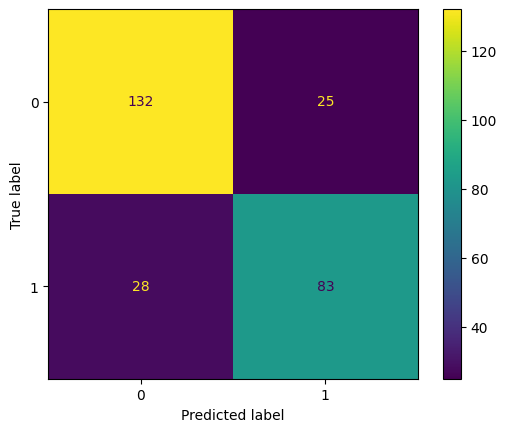

In [172]:
cm = confusion_matrix(y_test, y_predict_best)
ConfusionMatrixDisplay(cm).plot()

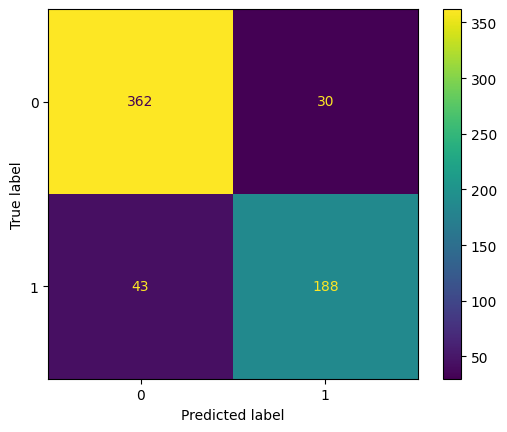

In [174]:
cm = confusion_matrix(y_train, y_predict_best1)
ConfusionMatrixDisplay(cm).plot()

In [176]:
print(classification_report(y_test, model_rf_best_params.predict(x_test)))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       157
           1       0.77      0.75      0.76       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.80      0.80      0.80       268



In [177]:
print(classification_report(y_train,model_rf_best_params.predict(x_train)))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91       392
           1       0.86      0.81      0.84       231

    accuracy                           0.88       623
   macro avg       0.88      0.87      0.87       623
weighted avg       0.88      0.88      0.88       623

